In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [76]:
# Importing warnings
import warnings
warnings.filterwarnings('ignore')

In [97]:
# Loading the data-set
data = pd.read_csv('../data/diabetes.csv')

data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [98]:
correlations = data.corr()['Outcome'].sort_values(ascending=False)
print(correlations)

Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64


In [78]:
# Checking for missing values
data.isnull().sum()

data.shape

(768, 9)

In [79]:
data.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

In [94]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
data.info()

<bound method DataFrame.info of      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   5

In [81]:
# Age min and max

print("Age min:", np.min(data['Age']))
print("Age max:", np.max(data['Age']))

Age min: 21
Age max: 81


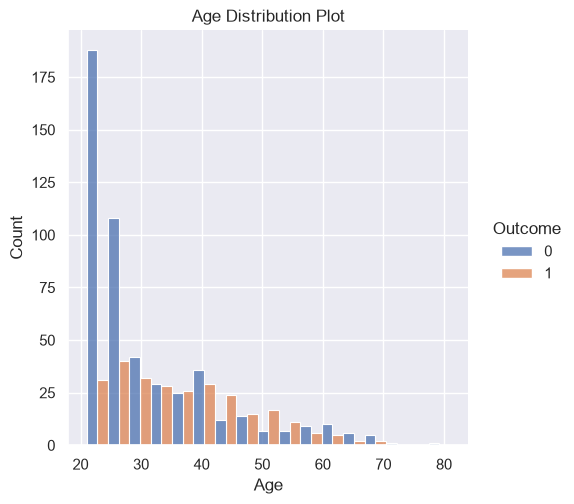

In [82]:
# We start our Univariate analysis
# We will check for DPF, Age, and Insulin

sns.set_theme()
sns.displot(data=data, x='Age', hue='Outcome', multiple='dodge')
plt.title("Age Distribution Plot")
plt.show()

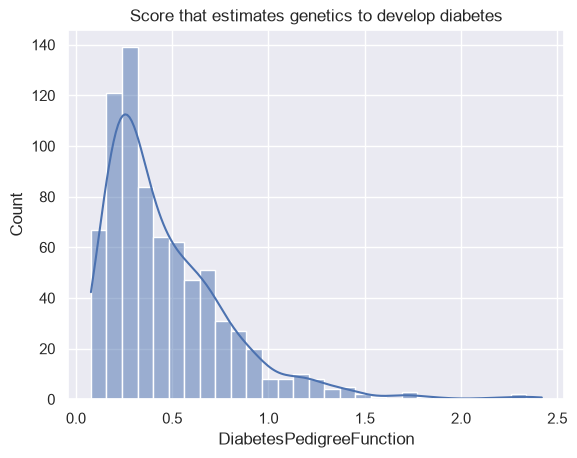

In [83]:
sns.histplot(data=data, x='DiabetesPedigreeFunction', kde=True)
plt.title("Score that estimates genetics to develop diabetes")
plt.show()

In [84]:
print(np.min(data['DiabetesPedigreeFunction']))
print(np.max(data['DiabetesPedigreeFunction']))

0.078
2.42


In [85]:
data['Insulin']

# I just want to check all the insulin counts
print(data.Insulin.unique())

[  0  94 168  88 543 846 175 230  83  96 235 146 115 140 110 245  54 192
 207  70 240  82  36  23 300 342 304 142 128  38 100  90 270  71 125 176
  48  64 228  76 220  40 152  18 135 495  37  51  99 145 225  49  50  92
 325  63 284 119 204 155 485  53 114 105 285 156  78 130  55  58 160 210
 318  44 190 280  87 271 129 120 478  56  32 744 370  45 194 680 402 258
 375 150  67  57 116 278 122 545  75  74 182 360 215 184  42 132 148 180
 205  85 231  29  68  52 255 171  73 108  43 167 249 293  66 465  89 158
  84  72  59  81 196 415 275 165 579 310  61 474 170 277  60  14  95 237
 191 328 250 480 265 193  79  86 326 188 106  65 166 274  77 126 330 600
 185  25  41 272 321 144  15 183  91  46 440 159 540 200 335 387  22 291
 392 178 127 510  16 112]


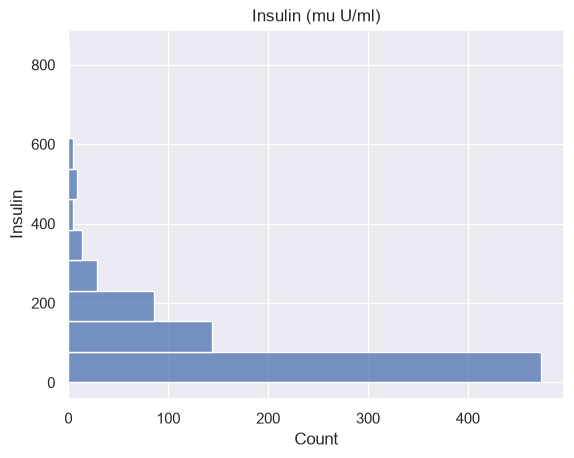

In [86]:
sns.histplot(data=data, y='Insulin', binwidth=75)
plt.title("Insulin (mu U/ml)")
plt.show()

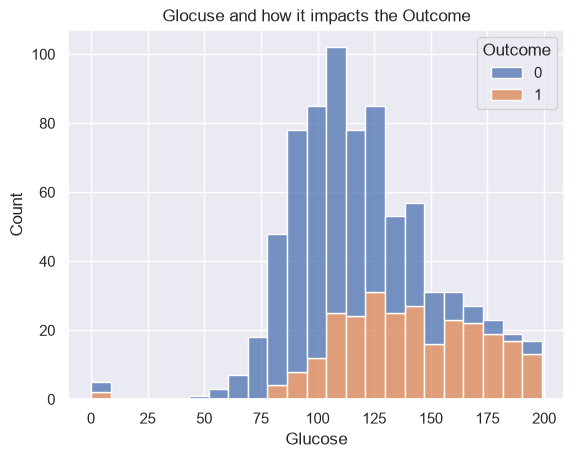

In [93]:
# Glucose vs Outcome 

sns.histplot(data=data, x='Glucose', hue='Outcome', multiple='stack')
plt.title("Glocuse and how it impacts the Outcome")
plt.show()

In [87]:
# Pregnancies
print("Minimum pregnany: ",min(data['Pregnancies']))
print("Maximum pregnany: ",max(data['Pregnancies']))

Minimum pregnany:  0
Maximum pregnany:  17


<Figure size 1200x1200 with 0 Axes>

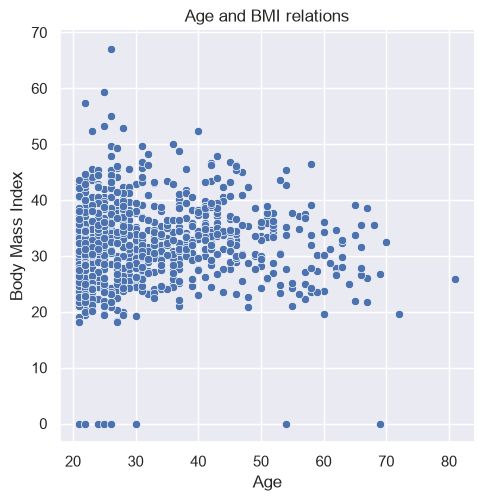

In [88]:
# Bi-variate analysis
# BMI and Age

plt.figure(figsize=(12, 12))
sns.relplot(data=data, x='Age', y='BMI')
plt.title("Age and BMI relations")
plt.ylabel("Body Mass Index")
plt.show()

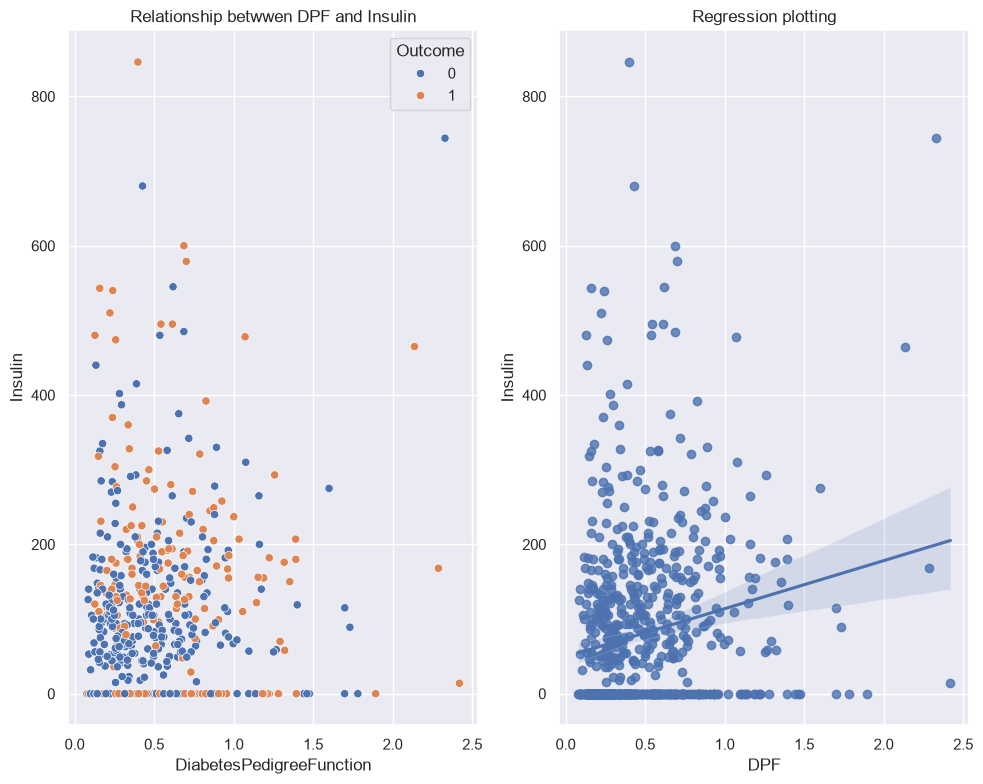

In [89]:
# Insulin and DiabetesPredigreeFuntion(DPF)

fig, axes = plt.subplots(1, 2, figsize=(10, 8))

sns.scatterplot(data=data, y='Insulin', x='DiabetesPedigreeFunction', hue='Outcome', ax=axes[0])
plt.xlabel("DPF")
axes[0].set_title("Relationship betwwen DPF and Insulin")

sns.regplot(data=data, y='Insulin', x='DiabetesPedigreeFunction', ax=axes[1])
plt.xlabel("DPF")
axes[1].set_title("Regression plotting")

plt.tight_layout()
plt.show()

<Axes: xlabel='BMI', ylabel='Glucose'>

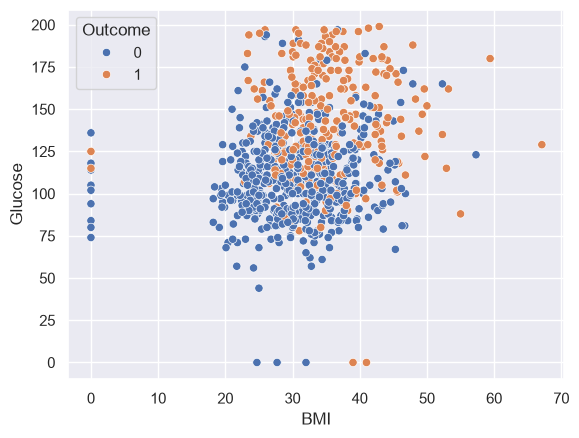

In [95]:
# Glucose vs BMI on the Outcome

sns.scatterplot(data=data, x='BMI', y='Glucose', hue='Outcome')

<Axes: >

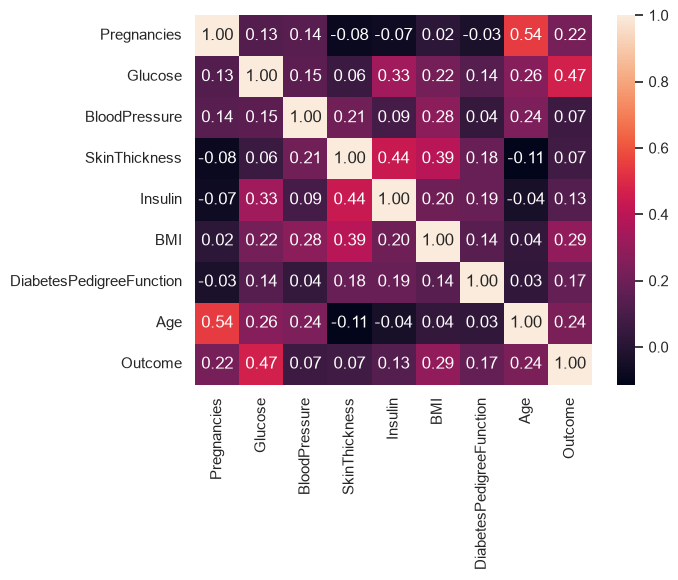

In [90]:
# Coorelation

coorelation_matrix = data.corr()

sns.heatmap(data=coorelation_matrix, annot=True, fmt='.2f')

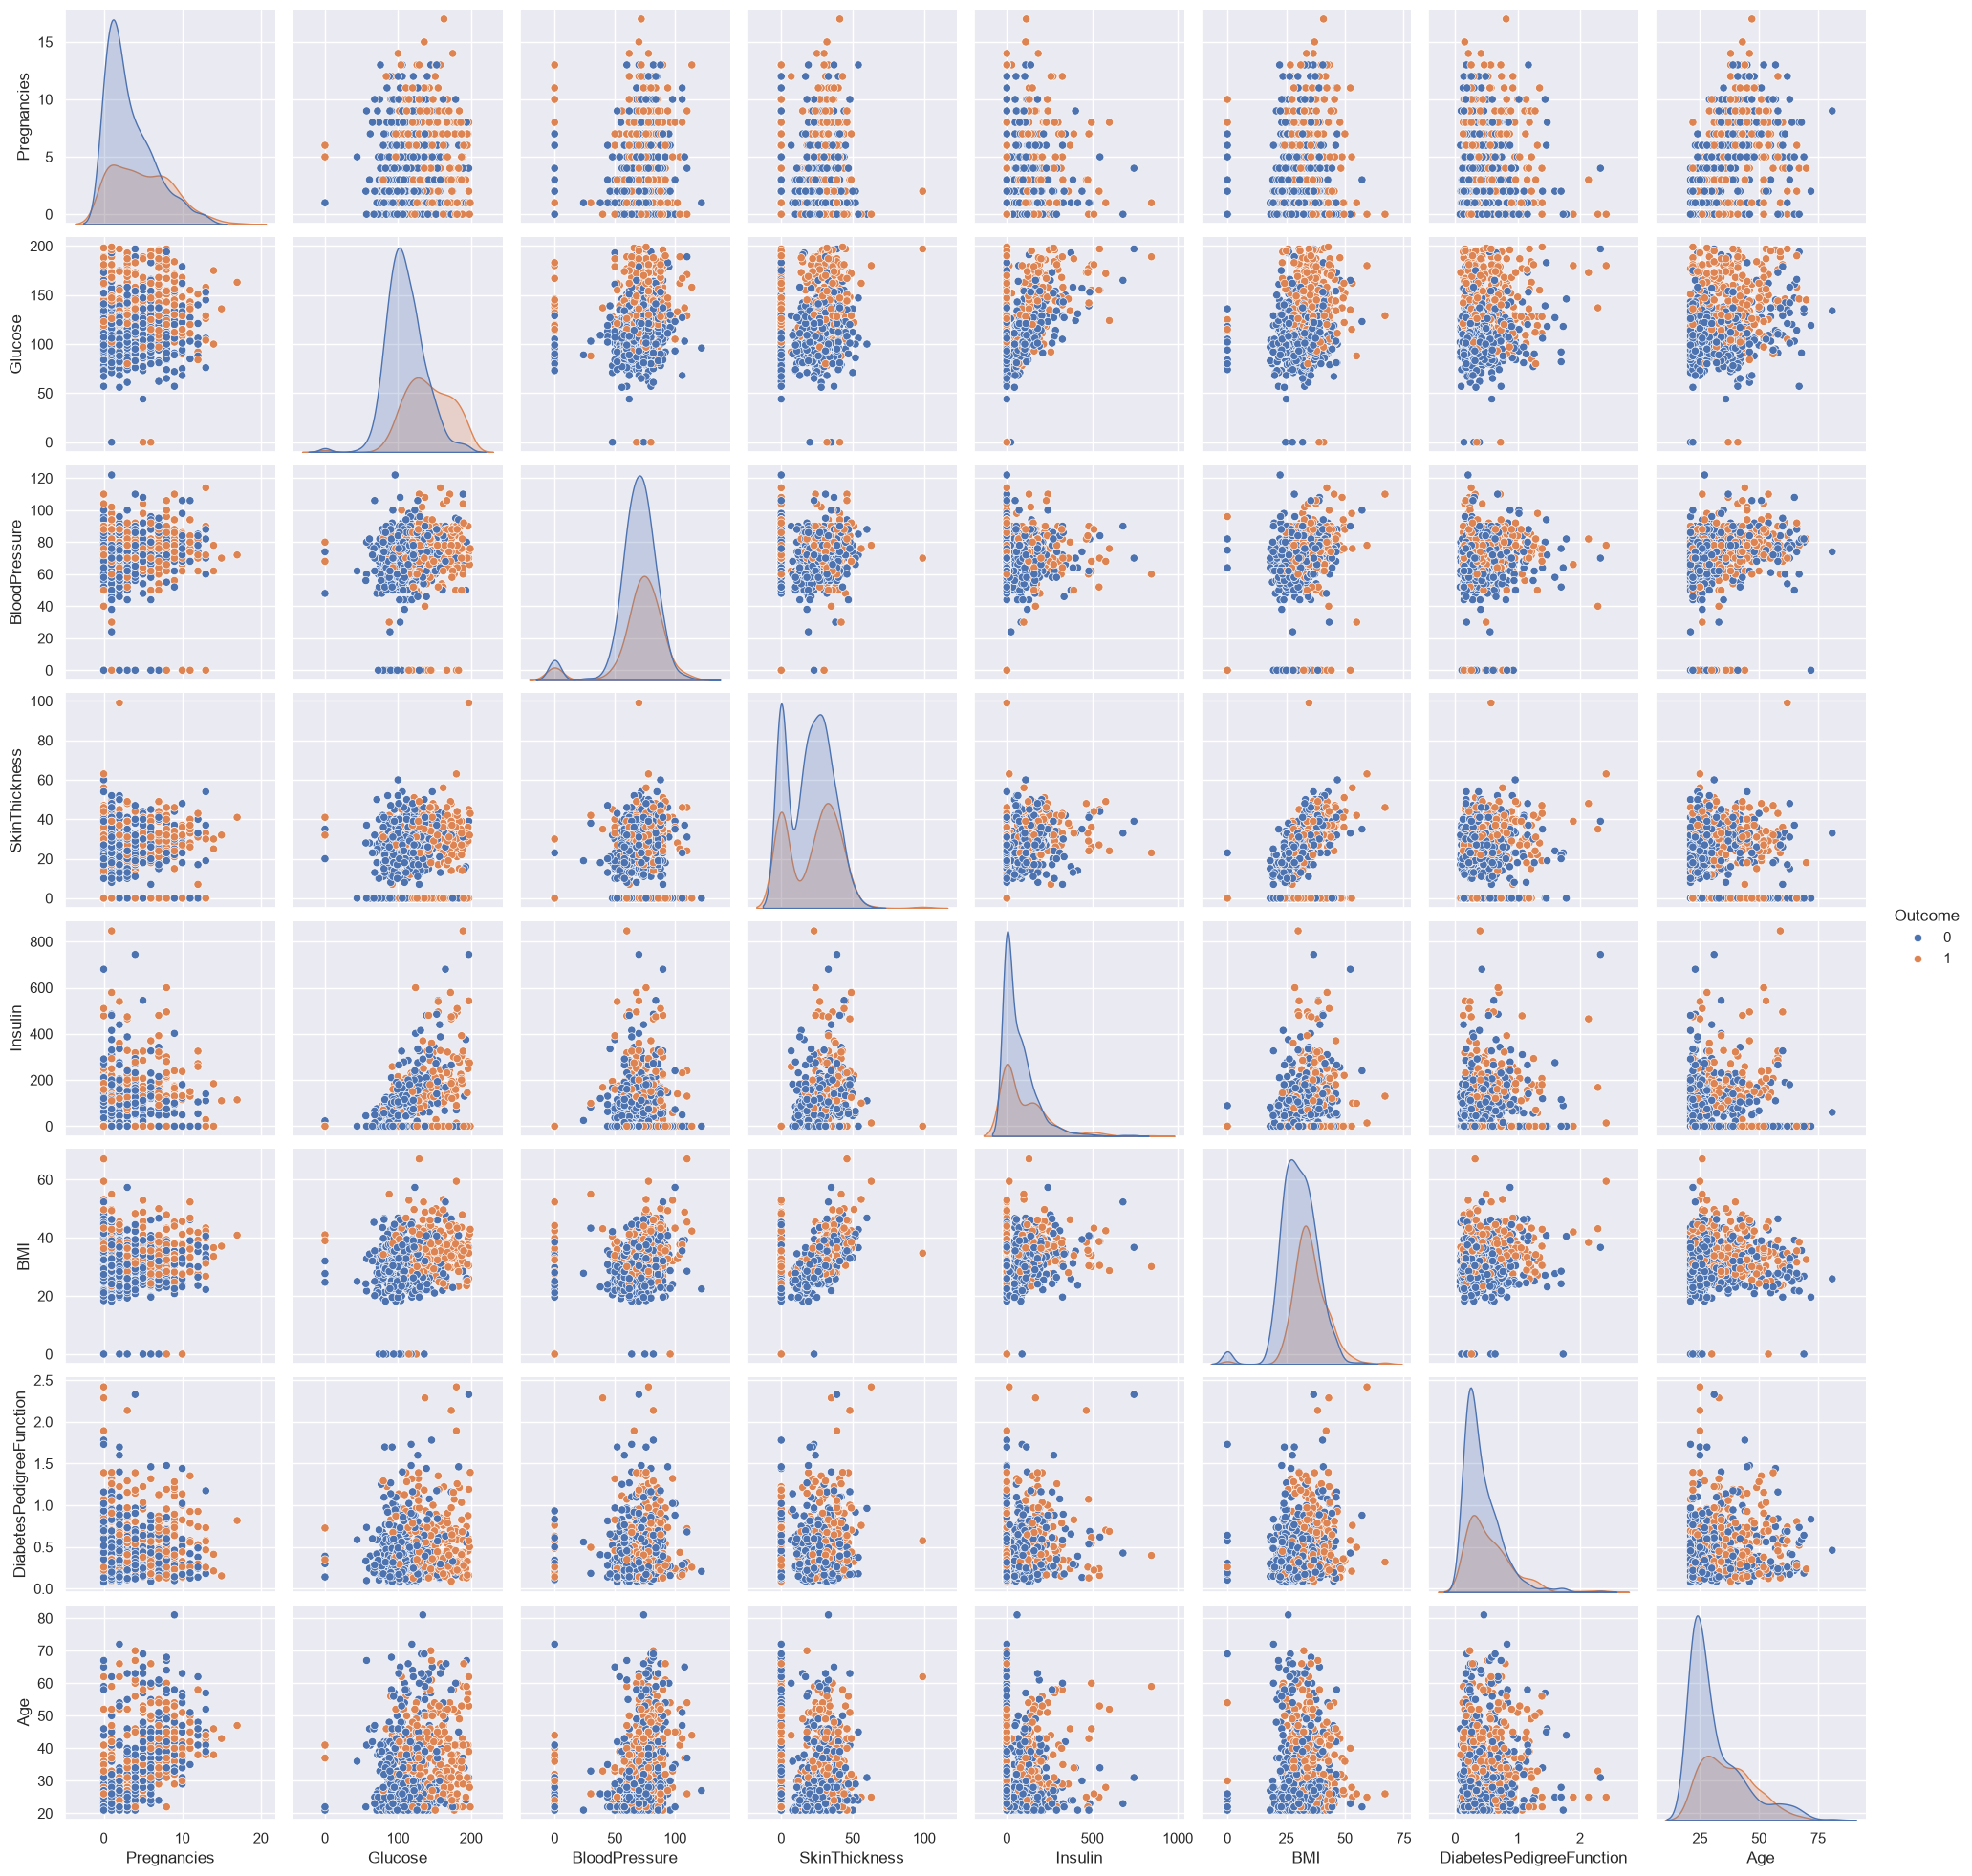

In [91]:
sns.pairplot(data=data, hue='Outcome')